In [1]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)

# LangSmith 추적: API 키와 추적 on/off는 .env에서 읽고, 프로젝트 이름만 여기서 정한다
# (.env에 LANGSMITH_PROJECT가 있으면 그 값을 쓴다)
os.environ.setdefault("LANGSMITH_PROJECT", "SKALA-KVCACHE")
print("LangSmith 프로젝트:", os.environ["LANGSMITH_PROJECT"])

LangSmith 프로젝트: SKALA-KVCACHE


# Orchestrator-Workers (전문 워커 버전) — KV Cache 기술 평가

`orchestrator_workers.ipynb`(범용 워커 1종)와 같은 흐름이고, **워커만 관점별 전문 워커**로 바꾼 버전.

```
START → orchestrator → (Send) 전문 워커 × N → synthesizer → END
```

**워커 4종** — 기존 에이전트의 프롬프트(`prompts/*.txt`)와 평가 기준을 그대로 사용

| 워커 | 자료 | 역할 |
|---|---|---|
| `tech_research` | RAG + 대조 기술 RAG | 기술 개요, 적용 범위, 한계, TRL |
| `market_eval` | 웹검색 | 시장 규모·CAGR, 도입 기업 수, 생태계 |
| `stakeholder_eval` | RAG + 웹검색 | 경쟁사, 도입 기업/개발자, 투자업계 반응 |
| `domain_eval` | RAG + 웹검색 | 처리 가능 규모, 비용 절감 효과 |

**범용 워커 버전과의 차이**

| | 범용 워커 버전 | 전문 워커 버전 (이 노트북) |
|---|---|---|
| Orchestrator가 정하는 것 | 관점 이름, 지시, 사용할 자료까지 전부 | 어떤 워커를 **몇 번**, **어떻게 나눠**, **무엇에 집중해서** 부를지 |
| 평가 기준의 위치 | Orchestrator의 계획 프롬프트 | 워커별 프롬프트 (기존 파일 그대로) |
| 새 관점 추가 | 계획만으로 가능 | 워커 4종 범위 안에서만 가능 |
| 결과 형식 | 관점마다 자유 형식 | 워커별로 정해진 출력 형식 → 안정적 |

워커 종류는 고정이지만 **어떤 워커를 몇 개 띄울지는 계획이 정하므로** 고정 fan-out은 아님 (워커로 가는 고정 엣지 없음, `Send`로 분배).

## 1. 기본 구성

- LLM, 검색 도구, 프롬프트 파일은 기존 프로젝트 것을 재사용
- 프로젝트 루트에서 실행해야 함 (`prompts/`, `data/raw`, `.cache`가 상대 경로)

In [2]:
import operator
import uuid
from pathlib import Path
from typing import Annotated, List, Literal, Optional, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_tavily import TavilySearch
from pydantic import BaseModel, Field

from agents.prompt_utils import rag_references, web_references, web_search
from rag.pdf import (
    format_docs,
    get_hw_comparison_retrieval_chain,
    get_sw_comparison_retrieval_chain,
    get_tech_retrieval_chain,
)

In [3]:
WORKER_MODEL = "gpt-5.6-luna"    # 워커 (기존 평가 에이전트와 동일)
PLANNER_MODEL = "gpt-5.6-terra"  # Orchestrator / Synthesizer

MAX_ATTEMPTS = 2  # task별 시도 상한 (종료 보장)

web_search_tool = TavilySearch(max_results=5)

## 2. STATE 정의

- 범용 워커 버전과 같은 구조. `Task`에 **어떤 워커가 처리할지(`worker`)** 가 들어가고, 자료 종류(`sources`)는 워커가 이미 알고 있으므로 빠짐
- **제어 / 결과 분리**: `tasks`(상태, 시도 횟수, 에러)와 `results`(본문, 출처)를 같은 `task_id`로 나눔
- **리듀서**: 병렬 워커가 동시에 쓰는 필드에는 모두 리듀서가 붙어 있고, 각 워커는 **자기 `task_id` 항목만** 반환

In [4]:
WorkerName = Literal["tech_research", "market_eval", "stakeholder_eval", "domain_eval"]
WORKERS = ["tech_research", "market_eval", "stakeholder_eval", "domain_eval"]


class Task(TypedDict, total=False):
    """제어 메타: 분배와 실패 대응 판단에 쓰는 정보."""

    task_id: str
    worker: WorkerName                        # 이 task를 처리할 전문 워커
    perspective: str                          # 화면/보고서에 쓸 짧은 이름
    instruction: str                          # 이번 조사에서 집중할 내용
    search_query: str                         # 검색에 쓸 짧은 키워드
    target: Optional[Literal["sw", "hw"]]     # 특정 기술만 다루면 지정
    status: Literal["pending", "done", "failed", "excluded"]
    attempts: int
    error: Optional[str]                      # 실패/부분 실패 사유


class TaskResult(TypedDict):
    """페이로드: 워커 결과물."""

    content: str
    references: List[str]


class Decision(TypedDict):
    """결정 1건과 그 사유 (관측성)."""

    node: str                                 # 결정을 내린 노드
    action: Literal["plan", "retry", "continue", "exclude"]
    task_ids: List[str]
    reason: str


def merge_tasks(left: dict, right: dict) -> dict:
    merged = dict(left)
    for task_id, patch in right.items():
        merged[task_id] = {**merged.get(task_id, {}), **patch}
    return merged


def merge_results(left: dict, right: dict) -> dict:
    return {**left, **right}


class GraphState(TypedDict):
    # 입력
    tech_sw: str
    tech_hw: str
    domain: str
    # 제어
    run_id: str                                               # 체크포인트 thread_id / 트레이스 태그와 공유
    tasks: Annotated[dict, merge_tasks]                       # task_id -> Task
    decisions: Annotated[List[Decision], operator.add]
    # 결과
    results: Annotated[dict, merge_results]                   # task_id -> TaskResult
    synthesis: str


class WorkerInput(TypedDict):
    # Send로 각 워커에 전달되는 개별 입력 (전체 State가 아님)
    task: Task
    tech_sw: str
    tech_hw: str
    domain: str

## 3. 계획 스키마

- Orchestrator의 구조화 출력. `worker`는 등록된 4종 중에서만 고를 수 있음
- `task_id`, `status`, `attempts` 같은 제어 값은 LLM이 아니라 코드가 붙임

In [5]:
class PlannedTask(BaseModel):
    worker: WorkerName = Field(description="이 task를 처리할 워커")
    perspective: str = Field(description="task를 구분할 짧은 이름 (예: '시장성 - HW', '도메인 - 비용')")
    instruction: str = Field(description="이번 조사에서 특히 집중할 내용 1~3문장")
    search_query: str = Field(description="검색에 쓸 핵심 키워드. 기술명을 포함해 100자 이내")
    target: Optional[Literal["sw", "hw"]] = Field(
        description="한쪽 기술만 다루면 'sw' 또는 'hw', 두 기술을 함께 다루면 null. "
        "tech_research는 반드시 지정"
    )


class Plan(BaseModel):
    tasks: List[PlannedTask] = Field(description="서로 독립적으로 병렬 수행 가능한 task 목록")
    reason: str = Field(description="이렇게 계획한 이유 1~2문장")

## 4. Orchestrator 노드

- 실행 **전에 한 번** LLM이 전체 평가를 task N개로 나누고, task마다 **어떤 전문 워커가 맡을지** 지정
- 같은 워커를 여러 번 부를 수 있음 (예: 시장 평가를 SW / HW로 나누기, 도메인 평가를 규모 / 비용으로 나누기)
- 평가 기준 자체는 워커 프롬프트에 있으므로, Orchestrator는 **분할 방식과 집중할 내용**을 정함
- Orchestrator는 **최종 보고서의 평가 관점 5개**(기술성숙도 / 시장성 / 이해관계자 / 도메인 적용 / 종합의견)를 알고 계획함. 앞의 네 관점은 워커와 1:1로 대응하고, 종합의견은 Synthesizer 몫이라 계획하지 않음
- **관점 커버리지 보장**: 계획이 나온 뒤 코드가 "네 관점 각각에서 SW와 HW가 모두 조사되는가"를 확인하고, 빠진 부분은 기본 task로 보완 (보완 사실은 `decisions`에 기록). 확인하는 것은 **빠진 기술이 없는지**까지이고, 두 기술을 같은 깊이로 조사하라고 요구하지는 않음 → task를 기술별로 몇 개씩 둘지는 Orchestrator가 정함
- 계획 생성 자체가 실패하면 기본 계획으로 대체하고, 그 사실을 `decisions`에 기록

In [6]:
# 워커와 보고서 평가 관점의 대응. 종합의견은 워커가 아니라 Synthesizer가 맡는다
VIEWPOINTS = {
    "tech_research": "기술성숙도 관점",
    "market_eval": "시장성 관점",
    "stakeholder_eval": "이해관계자 관점",
    "domain_eval": "도메인 적용 관점",
}

planner_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
planner = planner_llm.with_structured_output(Plan)

PLAN_PROMPT = """당신은 KV cache 최적화 기술 평가를 조율하는 Orchestrator입니다.
아래 두 기술을 평가하기 위해, 서로 '독립적으로' 병렬 수행할 수 있는 task로 분해하고
task마다 담당 워커를 지정하세요.
이 평가의 목적은 두 기술의 우열을 가리거나 하나를 추천하는 것이 아니라, 관점별로 각 기술의 특성과
근거를 정리하는 것입니다. 어느 한쪽에 유리한 근거만 찾도록 task를 짜지 마세요.

- SW 기술: {tech_sw}
- HW 기술: {tech_hw}
- 평가 도메인: {domain}

[최종 보고서의 평가 관점]
보고서의 "관점별 평가"는 아래 다섯 관점으로 구성됩니다. 계획은 이 관점들을 채울 근거를 모으기 위한 것입니다.
앞의 네 관점은 관점마다 정해진 워커가 조사하고, 종합의견은 워커 결과가 모인 뒤 따로 작성됩니다.

1. 기술성숙도 관점 ← tech_research 워커
   원문 논문에서 기술 개요, 적용 범위, 한계를 추출하고 TRL(Technology Readiness Level) 9단계 척도로
   성숙도를 추정. 공개 정보 기반 추정이며 논문 발표 시점과 실제 채택 간 시차가 있다는 점을 다룸.
   한 번에 한 기술만 처리(target 필수)
2. 시장성 관점 ← market_eval 워커 (웹검색)
   ① 시장 규모·성장성(시장 리포트, 산업 뉴스) ② 상용화·채택 현황(실제 도입 사례, 제품 출시 발표)
   ③ 생태계 지지(지원 프레임워크, 표준화 동향)
3. 이해관계자 관점 ← stakeholder_eval 워커 (원문 + 웹검색)
   ① 경쟁 기술 진영(경쟁사 반응, 대응 기술) ② 도입 기업·개발자(도입 의견, 채택 시 장벽)
   ③ 투자 업계(투자 동향, 애널리스트/미디어 평가)
4. 도메인 적용 관점 ← domain_eval 워커 (원문 + 웹검색)
   같은 기술도 적용 환경에 따라 평가가 달라짐. 이번에는 "{domain}" 도메인을 선택해,
   이 도메인이 민감한 요소(규모, 비용 등)를 기준으로 처리 가능 규모와 비용 절감 효과를 조사
5. 종합 의견 ← 워커 없음 (계획하지 마세요)
   1~4번 관점의 의견을 종합하되 관점 간 상충 지점이 명시적으로 드러나도록 객관적·중립적으로 작성.

[규칙]
- 네 관점을 하나도 빠뜨리지 말고, 관점마다 SW와 HW가 모두 조사되게 하세요
  (두 기술을 함께 다루는 task 하나, 또는 target을 나눈 task 두 개).
- 한 관점을 기술별로 나눴다면 SW와 HW에 같은 기준을 적용하세요.
- 관점 안에서 범위가 넓으면 위 ①②③ 같은 세부 기준 단위로 task를 더 나눠도 됩니다.
  단, 한 관점의 세부 기준이 어느 task에서도 다뤄지지 않는 일이 없게 하세요.
- perspective는 "관점 이름 - 세부"로 쓰세요 (예: "시장성 관점 - HW", "도메인 적용 관점 - 비용").
- instruction에는 두 기술의 성격을 고려해 그 관점에서 특히 확인해야 할 점을 쓰세요.
- task는 최소 10개 최대 20개, 다른 task의 결과에 의존하지 않아야 합니다."""

# 계획 생성이 실패했을 때 쓰는 기본 계획
DEFAULT_PLAN = [
    {"worker": "tech_research", "perspective": "기술성숙도 관점 - SW", "target": "sw",
     "instruction": "기술 개요, 적용 범위, 한계를 정리하고 TRL 9단계 척도로 성숙도를 추정한다.",
     "search_query": "{tech_sw}"},
    {"worker": "tech_research", "perspective": "기술성숙도 관점 - HW", "target": "hw",
     "instruction": "기술 개요, 적용 범위, 한계를 정리하고 TRL 9단계 척도로 성숙도를 추정한다.",
     "search_query": "{tech_hw}"},
    {"worker": "market_eval", "perspective": "시장성 관점", "target": None,
     "instruction": "두 기술 각각의 시장 규모·성장성, 상용화·채택 현황, 생태계 지지를 우열 판정 없이 정리한다.",
     "search_query": "{tech_sw} {tech_hw} 시장 규모 CAGR 채택 사례"},
    {"worker": "stakeholder_eval", "perspective": "이해관계자 관점", "target": None,
     "instruction": "경쟁 기술 진영, 도입 기업·개발자(채택 장벽 포함), 투자 업계의 시각을 정리한다.",
     "search_query": "{tech_sw} {tech_hw} 경쟁사 대응 도입 사례 투자 동향"},
    {"worker": "domain_eval", "perspective": "도메인 적용 관점", "target": None,
     "instruction": "{domain} 도메인이 민감한 요소를 기준으로 처리 가능한 규모, 비용 절감 효과, 제약을 정리한다.",
     "search_query": "{tech_sw} {tech_hw} {domain} scalability TCO energy efficiency"},
]

In [7]:
def _split_tech_research(planned: list[dict]) -> list[dict]:
    """tech_research는 한 번에 한 기술만 처리하므로, target이 없으면 SW/HW 두 task로 나눈다."""
    normalized = []
    for task in planned:
        if task["worker"] == "tech_research" and task.get("target") is None:
            for target in ("sw", "hw"):
                normalized.append({**task, "target": target,
                                   "perspective": f"{task['perspective']} - {target.upper()}"})
        else:
            normalized.append(task)
    return normalized


def _ensure_coverage(planned: list[dict], names: dict) -> tuple[list[dict], list[str]]:
    """네 관점 각각에서 SW와 HW가 모두 조사되는지 확인하고, 빠진 부분은 기본 task로 보완한다.
    보완한 내용을 사유로 돌려준다 (decisions에 기록)."""
    added: list[str] = []
    for worker, viewpoint in VIEWPOINTS.items():
        targets = {task.get("target") for task in planned if task["worker"] == worker}
        if None in targets or {"sw", "hw"} <= targets:
            continue
        base = next(task for task in DEFAULT_PLAN if task["worker"] == worker)
        if not targets and worker != "tech_research":
            missing = [None]                       # 관점이 통째로 빠짐 -> 두 기술을 함께 다루는 task 하나
        else:
            missing = [t for t in ("sw", "hw") if t not in targets]
        for target in missing:
            label = f"{viewpoint} - {target.upper()}" if target else viewpoint
            planned.append({**base, "target": target, "perspective": label,
                            "instruction": base["instruction"].format(**names),
                            "search_query": base["search_query"].format(**names)})
            added.append(label)
    return planned, added


def _label(task: dict) -> str:
    """task 이름이 어느 평가 관점에 속하는지 항상 드러나게 한다."""
    viewpoint = VIEWPOINTS[task["worker"]]
    name = task["perspective"]
    return name if name.replace(" ", "").startswith(viewpoint.replace(" ", "")) else f"{viewpoint} - {name}"


def orchestrator(state: GraphState):
    names = {"tech_sw": state["tech_sw"], "tech_hw": state["tech_hw"], "domain": state["domain"]}
    try:
        plan = planner.invoke(PLAN_PROMPT.format(**names))
        planned = [task.model_dump() for task in plan.tasks]
        if not planned:
            raise ValueError("빈 계획")
        reason = plan.reason
    except Exception as e:
        planned = [
            {**task, "instruction": task["instruction"].format(**names),
             "search_query": task["search_query"].format(**names)}
            for task in DEFAULT_PLAN
        ]
        reason = f"계획 생성 실패({e})로 기본 계획 사용"

    # task_id, status 같은 제어 값은 코드가 붙인다. task_id는 "워커명-순번"
    planned, added = _ensure_coverage(_split_tech_research(planned), names)
    if added:
        reason += f" / 계획에 빠져 있어 보완한 관점: {', '.join(added)}"

    tasks: dict = {}
    counts: dict = {}
    for task in planned:
        task = {**task, "perspective": _label(task)}
        counts[task["worker"]] = counts.get(task["worker"], 0) + 1
        task_id = f"{task['worker']}-{counts[task['worker']]}"
        tasks[task_id] = {**task, "task_id": task_id, "status": "pending",
                          "attempts": 0, "error": None}

    print(f"🧩 계획된 task {len(tasks)}개: {reason}")
    for task_id, task in tasks.items():
        print(f"   {task_id}: {task['perspective']} (target={task['target']})")

    return {
        "tasks": tasks,
        "decisions": [{"node": "orchestrator", "action": "plan",
                       "task_ids": list(tasks), "reason": reason}],
    }

## 5. Worker 노드

### 5-1. 공통 부분

- **프롬프트**: 기존 `prompts/*.txt`를 그대로 읽고, 끝에 Orchestrator의 지시를 받는 `{instruction}` 자리만 덧붙임
- **자료 수집 헬퍼**: `search_rag`, `search_web`은 실패해도 예외를 내지 않고 `(본문, 출처, 에러)`를 반환
- **재시도 (Fall-back 1)**: `run_with_retry`가 워커의 1회 실행 함수를 `MAX_ATTEMPTS`까지 다시 시도하고, 반환 형식을 통일
  - 출력은 **자기 `task_id` 항목만** 담은 `tasks`, `results`
  - 끝까지 실패하면 `status: "failed"`로 반환 (제외 여부는 Synthesizer가 판정)

In [8]:
INSTRUCTION_SUFFIX = """

[이번 조사에서 집중할 내용]
{instruction}

[작성 원칙]
- 두 기술의 우열을 판정하거나 한쪽을 추천하지 마세요. 각 기술의 특성을 근거와 함께 사실대로 정리하세요.
- 유리한 근거만 고르지 말고, 자료에 있는 한계와 반대 근거도 함께 쓰세요.
"""


def load_worker_prompt(path: str) -> PromptTemplate:
    """기존 프롬프트 파일에 Orchestrator 지시 자리를 덧붙인다."""
    return PromptTemplate.from_template(Path(path).read_text(encoding="utf-8") + INSTRUCTION_SUFFIX)


worker_llm = init_chat_model(WORKER_MODEL, model_provider="openai", temperature=0)

tech_research_chain = load_worker_prompt("prompts/tech_research.txt") | worker_llm | StrOutputParser()
market_chain = load_worker_prompt("prompts/market_eval.txt") | worker_llm | StrOutputParser()
stakeholder_chain = load_worker_prompt("prompts/stakeholder_eval.txt") | worker_llm | StrOutputParser()
domain_chain = load_worker_prompt("prompts/domain_eval.txt") | worker_llm | StrOutputParser()

In [9]:
def search_rag(get_chain, query: str, label: str = "RAG"):
    """RAG 검색. (본문, 출처, 에러)를 반환하고 실패 시 본문은 빈 문자열이다."""
    try:
        docs = get_chain().retriever.invoke(query)
        return format_docs(docs), rag_references(docs), None
    except Exception as e:
        return "", [], f"{label} 검색 실패: {e}"


def search_web(query: str):
    """웹검색. 제목/URL/본문만 골라 정리한다. 결과가 없으면 본문은 빈 문자열이다."""
    found = web_search(web_search_tool, query[:300])  # Tavily 쿼리 길이 제한 대비
    if not found.get("results"):
        return "", [], "웹검색 결과 없음"
    text = "\n\n".join(
        f"<web><title>{item.get('title')}</title><url>{item.get('url')}</url>"
        f"<content>{item.get('content')}</content></web>"
        for item in found["results"]
    )
    return text, web_references(found), None


def join_errors(*errors) -> Optional[str]:
    return "; ".join(e for e in errors if e) or None


def run_with_retry(state: WorkerInput, run_once, node: str):
    """run_once(state) -> (content, references, error)를 MAX_ATTEMPTS까지 시도한다.
    content가 None이거나 예외가 나면 실패로 본다."""
    task_id = state["task"]["task_id"]
    decisions: list[Decision] = []

    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            content, references, error = run_once(state)
        except Exception as e:
            content, references, error = None, [], f"{type(e).__name__}: {e}"
        if content is not None:
            return {
                "tasks": {task_id: {"status": "done", "attempts": attempt, "error": error}},
                "results": {task_id: {"content": content,
                                      "references": list(dict.fromkeys(references))}},
                "decisions": decisions,
            }
        if attempt < MAX_ATTEMPTS:
            decisions.append({"node": node, "action": "retry", "task_ids": [task_id],
                              "reason": f"{attempt}회 실패({error}), 재시도"})

    return {
        "tasks": {task_id: {"status": "failed", "attempts": MAX_ATTEMPTS, "error": error}},
        "decisions": decisions,
    }

### 5-2. 전문 워커 4종

- 워커마다 **쓰는 자료와 프롬프트가 고정**되어 있고, task에서 받는 것은 검색어와 집중할 내용뿐
- 자료를 여러 종류 쓰는 워커는 일부만 실패하면 남은 자료로 진행하고 `error`에 사유를 남김. 필요한 자료가 하나도 없으면 실패

In [10]:
def _tech_research_once(state: WorkerInput):
    """원문 RAG + 대조 기술 RAG. 원문이 없으면 실패."""
    task = state["task"]
    is_sw = task.get("target") != "hw"
    tech_name = state["tech_sw"] if is_sw else state["tech_hw"]

    chunks, refs, error = search_rag(get_tech_retrieval_chain, tech_name)
    if not chunks:
        return None, [], error

    get_comparison = get_sw_comparison_retrieval_chain if is_sw else get_hw_comparison_retrieval_chain
    comparison, comparison_refs, comparison_error = search_rag(
        get_comparison, "핵심 아이디어와 구조적 접근 방식", label="대조 기술 RAG"
    )
    content = tech_research_chain.invoke(
        {
            "tech_name": tech_name,
            "retrieved_chunks": chunks,
            "comparison_chunks": comparison,
            "instruction": task["instruction"],
        }
    )
    return content, refs + comparison_refs, join_errors(error, comparison_error)


def _market_once(state: WorkerInput):
    """웹검색만 사용. 검색 결과가 없으면 실패."""
    task = state["task"]
    web, refs, error = search_web(task["search_query"])
    if not web:
        return None, [], error
    content = market_chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "search_results": web,
            "instruction": task["instruction"],
        }
    )
    return content, refs, error


def _rag_and_web_once(state: WorkerInput, chain, extra_inputs: dict):
    """원문 RAG + 웹검색을 함께 쓰는 워커의 공통 흐름. 둘 다 없으면 실패."""
    task = state["task"]
    chunks, rag_refs, rag_error = search_rag(get_tech_retrieval_chain, task["search_query"])
    web, web_refs, web_error = search_web(task["search_query"])
    error = join_errors(rag_error, web_error)
    if not chunks and not web:
        return None, [], error
    content = chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "retrieved_chunks": chunks,
            "search_results": web,
            "supplement_search_results": "",
            "instruction": task["instruction"],
            **extra_inputs,
        }
    )
    return content, rag_refs + web_refs, error


def _stakeholder_once(state: WorkerInput):
    return _rag_and_web_once(state, stakeholder_chain, {})


def _domain_once(state: WorkerInput):
    return _rag_and_web_once(state, domain_chain, {"domain": state["domain"]})

In [11]:
# 그래프에 등록할 노드 함수 (이름은 Task.worker 값과 일치해야 함)
def tech_research(state: WorkerInput):
    return run_with_retry(state, _tech_research_once, "tech_research")


def market_eval(state: WorkerInput):
    return run_with_retry(state, _market_once, "market_eval")


def stakeholder_eval(state: WorkerInput):
    return run_with_retry(state, _stakeholder_once, "stakeholder_eval")


def domain_eval(state: WorkerInput):
    return run_with_retry(state, _domain_once, "domain_eval")

## 6. Fan-out 라우팅

- 계획된 task마다 **task에 적힌 워커**로 `Send` → 같은 워커가 여러 개 뜰 수도, 하나만 뜰 수도 있음
- 워커로 가는 **고정 엣지가 없음**. 어떤 워커가 몇 개 뜰지는 계획(State)을 읽어 결정 → Dynamic Fan-out

In [12]:
from langgraph.types import Send

In [13]:
def assign_workers(state: GraphState):
    return [
        Send(
            task["worker"],
            {"task": task, "tech_sw": state["tech_sw"], "tech_hw": state["tech_hw"],
             "domain": state["domain"]},
        )
        for task in state["tasks"].values()
    ]

## 7. Synthesizer 노드

- `results`에 누적된 워커 결과를 집계. task 개수가 실행마다 달라지므로 고정 자리 없이 **목록으로** 넣음
- **계속 / 제외 (Fall-back 2)**: 워커가 끝까지 실패한 task는 `excluded`로 바꿔 집계에서 빼고, 일부 자료만 실패한 task는 결과를 그대로 써서 계속 진행. 두 경우 모두 사유를 `decisions`에 기록하고 **자료 한계**로 전달

In [14]:
synth_prompt = ChatPromptTemplate.from_template(
    """당신은 여러 관점의 평가 결과를 종합하는 분석가입니다.
아래는 여러 워커가 병렬로 조사한 기술성숙도 관점, 시장성 관점, 이해관계자 관점, 도메인 적용 관점의 결과입니다.
이를 종합해 최종 보고서의 "종합 의견"이 될 내용을 작성하세요.

- SW 기술: {tech_sw}
- HW 기술: {tech_hw}
- 평가 도메인: {domain}

[원칙]
- 객관적이고 중립적으로 쓰세요. 어느 기술이 더 낫다고 판정하거나 특정 기술을 추천하지 마세요.
- 관점 간 상충 지점이 명시적으로 드러나야 합니다. 서로 어긋나는 평가를 평균 내거나 뭉개서 하나의 결론으로
  만들지 말고, "어느 관점에서는 A, 다른 관점에서는 B"라는 형태로 그대로 드러내세요.
- 아래 조사 결과에 있는 내용만 쓰고, 새로운 수치나 사례를 추가하지 마세요.
- 근거가 부족해 판단할 수 없는 부분은 "판단 유보"로 남기세요.

[관점별 조사 결과]
{joined}

[자료 한계]
{limitations}

[출력 형식]
- 관점별 핵심 결론: (네 관점 각각 1~2문장, 병렬 서술)
- 관점 간 일치하는 지점: (어느 관점들이 무엇에 대해 일치하는지, 관점 이름을 밝혀서)
- 관점 간 상충하는 지점: (어느 관점과 어느 관점이 무엇에 대해 어긋나는지, 각 관점의 근거와 함께)
- 판단 유보 사항: (근거 부족으로 결론을 내릴 수 없는 부분)
- 자료 한계: (위 [자료 한계]에 있는 항목만. 없으면 "없음")"""
)
synth_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
synth_chain = synth_prompt | synth_llm | StrOutputParser()


def collect_limitations(tasks: dict) -> list[str]:
    """제외되었거나 일부 자료가 실패한 task를 보고서 한계점 재료로 뽑는다."""
    return [
        f"{task['perspective']} ({'제외' if task['status'] == 'excluded' else '일부 자료 실패'}): "
        f"{task['error']}"
        for task in tasks.values()
        if task.get("error")
    ]


def collect_references(state: GraphState) -> list[str]:
    """종합에 쓰인 task들의 출처를 순서 유지 + 중복 제거해서 모은다."""
    refs = [
        ref
        for task_id, result in state["results"].items()
        if state["tasks"][task_id]["status"] == "done"
        for ref in result["references"]
    ]
    return list(dict.fromkeys(refs))

In [15]:
def synthesizer(state: GraphState):
    # --- Fall-back 판정: 실패한 task는 제외, 일부 자료만 실패한 task는 계속 ---
    updates: dict = {}
    decisions: list[Decision] = []
    for task_id, task in state["tasks"].items():
        if task["status"] == "failed":
            updates[task_id] = {"status": "excluded"}
            decisions.append({"node": "synthesizer", "action": "exclude", "task_ids": [task_id],
                              "reason": f"{task['attempts']}회 시도 후 결과 없음({task['error']})"})
        elif task.get("error"):
            decisions.append({"node": "synthesizer", "action": "continue", "task_ids": [task_id],
                              "reason": f"일부 자료 실패, 남은 자료로 계속({task['error']})"})
    tasks = merge_tasks(state["tasks"], updates)

    joined = "\n\n".join(
        f"### [{VIEWPOINTS[task['worker']]}] {task['perspective']}\n{state['results'][task_id]['content']}"
        for task_id, task in tasks.items()
        if task["status"] == "done"
    )
    limitations = collect_limitations(tasks)
    synthesis = synth_chain.invoke(
        {
            "tech_sw": state["tech_sw"],
            "tech_hw": state["tech_hw"],
            "domain": state["domain"],
            "joined": joined or "(조사 결과 없음)",
            "limitations": "\n".join(f"- {item}" for item in limitations) or "없음",
        }
    )
    return {"synthesis": synthesis, "tasks": updates, "decisions": decisions}

## 8. Graph 구성

- `orchestrator → (Send) 전문 워커 × N → synthesizer` : 워커가 모두 끝나면 Synthesizer가 한 번 실행
- 워커 노드 4개를 등록해 두지만, 실제로 어떤 노드가 몇 번 실행될지는 `assign_workers`가 계획을 읽어 결정
- **종료 보장**: 그래프에 되돌아가는 엣지가 없고, 워커 내부 재시도는 `MAX_ATTEMPTS`로 제한됨
- **재개/상관**: 체크포인터를 붙이고 `run_id`를 `thread_id`와 LangSmith 추적의 이름·태그·메타데이터로 함께 사용

In [16]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

In [17]:
WORKER_NODES = {
    "tech_research": tech_research,
    "market_eval": market_eval,
    "stakeholder_eval": stakeholder_eval,
    "domain_eval": domain_eval,
}

builder = StateGraph(GraphState)

builder.add_node("orchestrator", orchestrator)
for name, node in WORKER_NODES.items():
    builder.add_node(name, node)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")
# 조건부 엣지가 Send 리스트를 반환 -> 계획에 적힌 워커들로 병렬 fan-out
builder.add_conditional_edges("orchestrator", assign_workers, WORKERS)
for name in WORKER_NODES:
    builder.add_edge(name, "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile(checkpointer=MemorySaver())

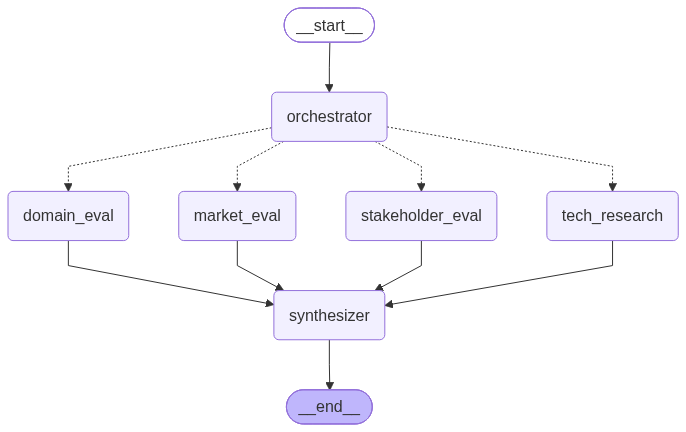

In [18]:
try:
    display(Image(graph.get_graph().draw_mermaid_png(max_retries=3, retry_delay=2.0)))
except Exception as e:
    # 그림은 외부 서비스(mermaid.ink)로 렌더링하므로 네트워크 상태에 따라 실패할 수 있다.
    # 그래프는 이미 컴파일되어 있어 아래 셀 실행에는 영향이 없고, 대신 mermaid 코드를 출력한다
    # (https://mermaid.live 에 붙여 넣으면 그림으로 볼 수 있다).
    print(f"그래프 이미지 렌더링 실패: {type(e).__name__}\n")
    print(graph.get_graph().draw_mermaid())

## 9. 실행

Orchestrator가 평가를 task로 분해하고 워커를 지정 → 전문 워커들이 병렬 조사 → Synthesizer가 하나로 집계하는 흐름 확인.

- 처음 실행하면 `.cache/chroma_index` 인덱스를 열고, 목록에 없는 출처는 정리하고 새 PDF만 임베딩함

In [19]:
run_id = uuid.uuid4().hex[:12]
# run_id를 체크포인트 thread_id와 LangSmith 추적(이름, 태그, 메타데이터)에 함께 사용
config = {
    "configurable": {"thread_id": run_id},
    "run_name": f"kv-cache-eval-specialized-{run_id}",
    "tags": ["orchestrator-workers", "specialized-workers", f"run:{run_id}"],
    "metadata": {"run_id": run_id},
}

result = graph.invoke(
    {
        "tech_sw": "DeepSeek-V2 (MLA)",
        "tech_hw": "ITME (Inference Tiered Memory Expansion)",
        "domain": "데이터센터/클라우드 서빙",
        "run_id": run_id,
        "tasks": {},
        "results": {},
        "decisions": [],
    },
    config=config,
)

print("\n===== 평가 종합 =====\n")
print(result["synthesis"])

🧩 계획된 task 10개: 기술성숙도는 원문 논문 해석과 TRL 추정이 기술별로 독립적이므로 분리하고, 나머지 관점은 동일한 세부 기준에서 두 기술의 공개 근거를 병렬 수집하도록 구성했습니다. 시장성·이해관계자·도메인 적용의 모든 필수 세부 기준을 포함하되, 우열이나 추천을 전제하지 않도록 긍정 근거와 제약·미채택 근거를 함께 확인하게 했습니다.
   tech_research-1: 기술성숙도 관점 - SW MLA (target=sw)
   tech_research-2: 기술성숙도 관점 - HW ITME (target=hw)
   market_eval-1: 시장성 관점 - 시장 규모·성장성 (target=None)
   market_eval-2: 시장성 관점 - 상용화·채택 (target=None)
   market_eval-3: 시장성 관점 - 생태계 지지 (target=None)
   stakeholder_eval-1: 이해관계자 관점 - 경쟁 기술 진영 (target=None)
   stakeholder_eval-2: 이해관계자 관점 - 도입 기업·개발자 (target=None)
   stakeholder_eval-3: 이해관계자 관점 - 투자 업계 (target=None)
   domain_eval-1: 도메인 적용 관점 - 처리 가능 규모 (target=None)
   domain_eval-2: 도메인 적용 관점 - 비용 절감 (target=None)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


===== 평가 종합 =====

## 관점별 핵심 결론

- **기술성숙도 관점:** DeepSeek-V2의 MLA는 모델 통합, 공개 구현 및 H100 기반 서빙 벤치마크가 확인되어 공개 정보 기준 **TRL 6**으로 추정된다. 반면 ITME는 FPGA 프로토타입과 통합 실험 검증은 제시되었으나 실제 데이터센터 운용·상용 도입 근거가 없어 **TRL 4~5**로 추정된다.

- **시장성 관점:** 두 기술 모두 장문 컨텍스트, RAG, 멀티턴 세션 증가에 따른 KV cache 부담이라는 성장 동인과 연결되지만, MLA 또는 ITME 자체의 시장 규모·매출·CAGR·고객 수는 확인되지 않는다. MLA는 모델·추론 소프트웨어 경로, ITME는 CXL·RDMA·스토리지 등을 포함한 인프라 조달·통합 경로를 통해 채택될 가능성이 제시된다.

- **이해관계자 관점:** MLA는 GQA·MQA, KV 양자화, eviction, sparse attention 등과 대안 관계에 있으며, DeepSeek 후속 모델의 채택과 SGLang·vLLM 등의 최적화 사례가 확인된다. ITME는 CPU 오프로딩, CXL 메모리 확장, CXL 메모리 풀링, NVIDIA CMX, CXL-PNM 등 인접 접근과 비교될 수 있으나, 두 기술 모두 실제 고객의 장기 운영 경험, 공식 경쟁사 대응, 투자업계 평가에는 근거가 부족하다.

- **도메인 적용 관점:** 데이터센터·클라우드 서빙에서 MLA는 KV cache의 표현 크기를 줄여 동일 GPU 메모리에서 긴 컨텍스트 또는 높은 동시성을 수용할 여지를 제공하는 모델·소프트웨어 접근이다. ITME는 GPU HBM을 초과하는 가중치와 KV cache를 CXL, 호스트 메모리, NVMe, RDMA, 공유 스토리지 계층으로 확장하는 인프라 접근이며, 성능은 프리페치 정확도와 계층 간 데이터 이동 관리에 의존한다.

## 관점 간 일치하는 지점

- **기술성숙도·시장성·이해관계자·도메인 적용 관점**은 모두 두 기술이 장문 컨텍스트, 높은

## 10. 결과 확인

State만 보고 **무엇을 계획했고, 왜 그렇게 결정했고, 어떻게 끝났는지** 확인.

In [20]:
def show_run(state: GraphState):
    print(f"run_id={state['run_id']}\n")
    print("[결정 로그]")
    for d in state["decisions"]:
        print(f"  {d['node']:<16} {d['action']:<8} {d['task_ids']} - {d['reason']}")
    print("\n[task 상태]")
    for task_id, task in state["tasks"].items():
        print(f"  {task_id:<19} {task['status']:<8} 시도 {task['attempts']} {task['perspective']}"
              + (f"  ! {task['error']}" if task.get("error") else ""))
    print("\n[자료 한계]")
    for item in collect_limitations(state["tasks"]) or ["없음"]:
        print(f"  - {item}")


show_run(result)

print("\n[참고 자료]")
for ref in collect_references(result):
    print(f"  - {ref}")

run_id=711fe07dc42d

[결정 로그]
  orchestrator     plan     ['tech_research-1', 'tech_research-2', 'market_eval-1', 'market_eval-2', 'market_eval-3', 'stakeholder_eval-1', 'stakeholder_eval-2', 'stakeholder_eval-3', 'domain_eval-1', 'domain_eval-2'] - 기술성숙도는 원문 논문 해석과 TRL 추정이 기술별로 독립적이므로 분리하고, 나머지 관점은 동일한 세부 기준에서 두 기술의 공개 근거를 병렬 수집하도록 구성했습니다. 시장성·이해관계자·도메인 적용의 모든 필수 세부 기준을 포함하되, 우열이나 추천을 전제하지 않도록 긍정 근거와 제약·미채택 근거를 함께 확인하게 했습니다.

[task 상태]
  tech_research-1     done     시도 1 기술성숙도 관점 - SW MLA
  tech_research-2     done     시도 1 기술성숙도 관점 - HW ITME
  market_eval-1       done     시도 1 시장성 관점 - 시장 규모·성장성
  market_eval-2       done     시도 1 시장성 관점 - 상용화·채택
  market_eval-3       done     시도 1 시장성 관점 - 생태계 지지
  stakeholder_eval-1  done     시도 1 이해관계자 관점 - 경쟁 기술 진영
  stakeholder_eval-2  done     시도 1 이해관계자 관점 - 도입 기업·개발자
  stakeholder_eval-3  done     시도 1 이해관계자 관점 - 투자 업계
  domain_eval-1       done     시도 1 도메인 적용 관점 - 처리 가능 규모
  domain_eval-2       done     시도 1 도메인 적용 관점 - 비용 절감

[자료 한계]
  - 없음

## 11. Fall-back 동작 확인

웹검색이 실패하는 상황을 만들어, 실패한 task가 **재시도 → 제외**로 처리되고도 그래프가 끝까지 도는지 확인.

- `market_eval`: 웹검색만 쓰므로 재시도 후에도 실패 → Synthesizer가 `excluded` 처리
- `stakeholder_eval`, `domain_eval`: RAG 자료로 결과를 만들고 `error`에 "웹검색 결과 없음"만 기록 (계속)
- `tech_research`: 웹검색을 쓰지 않으므로 영향 없음

In [21]:
class BrokenSearch:
    """항상 실패하는 웹검색 도구 (fall-back 확인용)."""

    def invoke(self, _):
        raise RuntimeError("웹검색 장애 (테스트)")


original_tool = web_search_tool
web_search_tool = BrokenSearch()
try:
    fail_run_id = uuid.uuid4().hex[:12]
    failed_result = graph.invoke(
        {
            "tech_sw": "DeepSeek-V2 (MLA)",
            "tech_hw": "ITME (Inference Tiered Memory Expansion)",
            "domain": "데이터센터/클라우드 서빙",
            "run_id": fail_run_id,
            "tasks": {},
            "results": {},
            "decisions": [],
        },
        config={
            "configurable": {"thread_id": fail_run_id},
            "run_name": f"kv-cache-eval-specialized-fallback-{fail_run_id}",
            "tags": ["orchestrator-workers", "specialized-workers", "fallback-test",
                     f"run:{fail_run_id}"],
            "metadata": {"run_id": fail_run_id},
        },
    )
finally:
    web_search_tool = original_tool

show_run(failed_result)

🧩 계획된 task 10개: 기술성숙도는 기술별 원문 분석과 TRL 추정이 필요하므로 독립 task로 분리하고, 나머지 관점은 각 세부 기준에서 두 기술을 같은 평가 기준으로 조사하도록 구성했습니다. 총 10개 task는 상호 결과를 전제하지 않으며, 시장·이해관계자·도메인 적용의 모든 필수 세부 기준을 포괄합니다.
   tech_research-1: 기술성숙도 관점 - SW MLA (target=sw)
   tech_research-2: 기술성숙도 관점 - HW ITME (target=hw)
   market_eval-1: 시장성 관점 - 시장 규모·성장성 (target=None)
   market_eval-2: 시장성 관점 - 상용화·채택 (target=None)
   market_eval-3: 시장성 관점 - 생태계 지지 (target=None)
   stakeholder_eval-1: 이해관계자 관점 - 경쟁 기술 진영 (target=None)
   stakeholder_eval-2: 이해관계자 관점 - 도입 기업·개발자 (target=None)
   stakeholder_eval-3: 이해관계자 관점 - 투자 업계 (target=None)
   domain_eval-1: 도메인 적용 관점 - 처리 가능 규모 (target=None)
   domain_eval-2: 도메인 적용 관점 - 비용 절감 (target=None)
[WARN] 웹검색 실패 (LLM inference KV cache market AI inference memory expansion datacenter CAGR MLA ITME): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (LLM inference KV cache market AI inference memory expansion datacenter CAGR MLA ITME): 웹검색 장애 (테스트)
[WARN] 웹검색 실패 (DeepSeek MLA production adoption cloud serving ITME Infer

## 12. 보고서 생성 + 품질 평가 Loop

Synthesizer 뒤에 기존 프로젝트의 **보고서 생성**(`agents/report_gen.py`, `prompts/report_gen.txt`)을 붙이고, 그 뒤에 **품질 평가 노드**를 추가. 평가에 미달하면 피드백을 들고 보고서 생성으로 되돌아감.

```
… → synthesizer → report_gen → quality_eval ─(통과)→ END
                      ↑             │
                      └──(미달)─────┘   최대 MAX_REVISIONS번 재작성
```

- 앞 구간(orchestrator → 워커 → synthesizer)은 **Orchestrator-Workers**, 이 구간은 **Evaluator-Optimizer** 패턴
- 앞에서 만든 노드와 State는 그대로 쓰고, State에 필드 3개만 추가

### 12-1. State 확장

- `report`: 최신 보고서 본문 (재작성하면 덮어씀)
- `review`: **최신 평가 1건** (덮어씀 → 누적되지 않음). 평가 이력은 `decisions`에 한 줄씩 남음
- `revision`: 보고서 작성 횟수 → Loop 종료 보장용
- `decisions`의 `action`에 `accept`(통과) / `revise`(재작성) / `stop`(미달인 채 종료) 가 추가로 쓰임

In [22]:
MAX_REVISIONS = 2  # 보고서 재작성 상한 (최초 작성 1회 + 재작성 최대 2회)


class CriterionResult(TypedDict):
    name: str        # 평가 항목
    passed: bool
    comment: str     # 판정 근거 / 미달 사유


class ReportReview(TypedDict):
    passed: bool                       # 모든 항목 통과 여부
    criteria: List[CriterionResult]
    feedback: str                      # 재작성 시 보고서 생성에 넘길 수정 지시
    error: Optional[str]               # 평가 자체가 실패한 경우의 사유


class ReportState(GraphState):
    report: str
    review: ReportReview
    revision: int

### 12-2. 보고서 생성 노드

- 기존 `prompts/report_gen.txt`를 그대로 사용. 프롬프트의 고정 자리(`{market_eval}` 등)에는 **같은 워커의 task 결과를 묶어서** 넣음 (워커가 여러 번 불렸으면 소제목으로 구분)
- `자료 부족 노드`에는 제외되었거나 일부 자료가 실패한 task를, `실제 참고 자료 목록`에는 종합에 쓰인 task의 출처를 중복 제거해서 넣음
- 재작성일 때는 프롬프트 끝에 **이전 보고서와 평가 피드백**을 덧붙임
- 기존 `outputs/report.md`를 덮어쓰지 않도록 다른 파일명으로 저장

In [23]:
REPORT_PATH = "outputs/report_orchestrator_workers.md"

REVISION_SUFFIX = """

[작성 원칙 - 품질 평가 기준]
- Groundedness: 모든 수치, 기업명, 사례, 평가 문장은 위 입력 자료에서 온 것이어야 하고,
  본문에서 어느 자료(원문 파일/페이지 또는 URL)에 근거했는지 드러나게 쓰세요.
- 중립성: 이 보고서는 두 기술의 우열을 가리는 문서가 아닙니다. 특정 기술을 추천하거나
  "더 우수하다/적합하다"고 판정하지 말고, 관점별 특성과 차이를 병렬로 서술하세요.
- 편향 통제: 두 기술 모두 강점과 한계를 함께 쓰고, 한 출처에만 기대어 결론을 내리지 마세요.
  두 기술의 서술 분량을 억지로 맞출 필요는 없습니다. 자료가 있는 만큼 쓰고, 없는 부분은 "근거 부족"으로 두세요.
- 관점 커버리지: "4. 관점별 평가"는 기술성숙도 관점, 시장성 관점, 이해관계자 관점, 도메인 적용 관점,
  종합의견 다섯 소제목을 이름 그대로 모두 갖춰야 합니다. 조사 결과가 없는 관점은 빼지 말고 "근거 부족"이라고 쓰세요.

[이전 보고서]
{previous_report}

[품질 평가 피드백]
{feedback}
위 피드백이 "없음"이 아니면, 이전 보고서에서 지적된 항목을 모두 고쳐 보고서 전체를 다시 작성하세요.
지적되지 않은 부분은 유지하고, 위 [출력 형식]과 근거 사용 규칙은 그대로 지키세요.
"""

report_prompt = PromptTemplate.from_template(
    Path("prompts/report_gen.txt").read_text(encoding="utf-8") + REVISION_SUFFIX
)
report_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
report_chain = report_prompt | report_llm | StrOutputParser()


def results_of(state: GraphState, worker: str, target: Optional[str] = None) -> str:
    """한 워커(필요하면 한 기술)가 만든 결과들을 묶어 프롬프트의 고정 자리에 넣을 문자열로 만든다."""
    parts = [
        f"#### {task['perspective']}\n{state['results'][task_id]['content']}"
        for task_id, task in state["tasks"].items()
        if task["worker"] == worker
        and task["status"] == "done"
        and (target is None or task.get("target") == target)
    ]
    return "\n\n".join(parts) or "근거 부족 (조사 결과 없음)"


def report_inputs(state: GraphState) -> dict:
    """보고서와 품질 평가가 함께 쓰는 근거 자료."""
    limitations = collect_limitations(state["tasks"])
    references = collect_references(state)
    return {
        "tech_sw": state["tech_sw"],
        "tech_hw": state["tech_hw"],
        "domain": state["domain"],
        "tech_research_sw": results_of(state, "tech_research", "sw"),
        "tech_research_hw": results_of(state, "tech_research", "hw"),
        "market_eval": results_of(state, "market_eval"),
        "stakeholder_eval": results_of(state, "stakeholder_eval"),
        "domain_eval": results_of(state, "domain_eval"),
        "synthesis": state.get("synthesis", ""),
        "data_limited": "\n".join(f"- {item}" for item in limitations) or "없음",
        "references": "\n".join(f"- {ref}" for ref in references) or "없음",
    }


def report_gen(state: ReportState):
    revision = state.get("revision", 0) + 1
    review = state.get("review") or {}
    print(f"\n==== [REPORT GEN] {revision}번째 작성 ====")

    report = report_chain.invoke(
        {
            **report_inputs(state),
            "previous_report": state.get("report") or "없음",
            "feedback": review.get("feedback") or "없음",
        }
    )

    os.makedirs("outputs", exist_ok=True)
    Path(REPORT_PATH).write_text(report, encoding="utf-8")
    print(f"{REPORT_PATH} 저장 완료")
    return {"report": report, "revision": revision}

### 12-3. 품질 평가 노드

과제의 평가 항목 4개로 판정. 이 평가의 목적은 **우열 판정이 아니라** 다관점 정리이므로, 보고서가 특정 기술을 추천하거나 한쪽에 유리하게 쓰였는지를 직접 검사함.

| 평가 항목 | 무엇을 보는가 | 방식 |
|---|---|---|
| Groundedness | 주장이 검색된 출처로 추적되는가 (Reference 연결성, Hallucination 통제) | 코드(지어낸 URL 검사) + LLM |
| 중립성 | 특정 기술 추천/우열 판정이 없는가 | LLM |
| 편향 통제 | 단일 출처, 유리한 근거 편중이 없는가 (확증편향 방지) | 코드(출처 다양성 검사) + LLM |
| 관점 커버리지 | 기술성숙도, 시장성, 이해관계자, 도메인 적용 4개 관점을 포괄하고 종합의견이 있는가 | 코드(소제목 5개, TRL의 '공개 정보 기반 추정' 명시, 종합의견의 상충 지점 명시) + LLM(관점별 세부 기준) |

- 편향 통제는 근거의 **선택**이 한쪽에 치우쳤는지를 봄. 두 기술의 조사 깊이나 분량이 다른 것 자체는 미달 사유가 아님 (계획 단계에서 같은 깊이로 조사하라는 제약을 두지 않으므로)
- 기계적으로 확인할 수 있는 부분은 **코드로 먼저 검사**하고, LLM 판정과 **둘 다 통과해야** 그 항목이 통과
- 하나라도 미달이면 미달 사유를 모아 `feedback`으로 만들고 보고서 생성으로 되돌림

In [24]:
import re
from urllib.parse import urlparse

URL_PATTERN = re.compile(r"https?://[^\s)>\]]+")


def _urls(text: str) -> set:
    return {url.rstrip(".,;") for url in URL_PATTERN.findall(text)}


def check_reference_links(report: str, references: list[str]) -> tuple[bool, str]:
    """Groundedness(코드): 보고서에 나온 URL이 모두 실제 참고 자료 목록에 있는가."""
    unknown = sorted(_urls(report) - _urls("\n".join(references)))
    if unknown:
        return False, f"참고 자료 목록에 없는 URL: {', '.join(unknown)}"
    return True, "보고서의 URL이 모두 참고 자료 목록에 있음"


# '4. 관점별 평가'에 반드시 있어야 하는 소제목 (prompts/report_gen.txt의 출력 형식과 일치)
REQUIRED_PERSPECTIVES = ["기술성숙도 관점", "시장성 관점", "이해관계자 관점", "도메인 적용 관점", "종합의견"]


def _section(report: str, name: str) -> Optional[str]:
    """제목에 name이 들어간 절의 본문을 돌려준다 (같거나 더 높은 수준의 다음 제목 전까지).
    띄어쓰기 차이('기술 성숙도 관점')는 같은 것으로 본다."""
    key = re.sub(r"\s+", "", name)
    lines = report.splitlines()
    for i, line in enumerate(lines):
        stripped = line.lstrip()
        if stripped.startswith("#") and key in re.sub(r"\s+", "", stripped):
            level = len(stripped) - len(stripped.lstrip("#"))
            body = []
            for nxt in lines[i + 1:]:
                s = nxt.lstrip()
                if s.startswith("#") and len(s) - len(s.lstrip("#")) <= level:
                    break
                body.append(nxt)
            return "\n".join(body)
    return None


def check_perspective_sections(report: str) -> tuple[bool, str]:
    """관점 커버리지(코드): 평가 관점 5개가 모두 소제목으로 있고, 명세가 '반드시' 요구한 두 가지
    (TRL이 공개 정보 기반 추정임을 명시, 종합의견에 상충 지점 명시)가 해당 절에 들어 있는가."""
    sections = {name: _section(report, name) for name in REQUIRED_PERSPECTIVES}
    problems = []
    missing = [name for name, body in sections.items() if body is None]
    if missing:
        problems.append(f"소제목이 없는 평가 관점: {', '.join(missing)}")

    trl = sections["기술성숙도 관점"]
    if trl is not None:
        if "TRL" not in trl:
            problems.append("기술성숙도 관점에 TRL 등급이 없음")
        if not re.search(r"공개\s*정보", trl):
            problems.append("기술성숙도 관점에 '공개 정보 기반 추정'이라는 명시가 없음")
    overall = sections["종합의견"]
    if overall is not None and "상충" not in overall:
        problems.append("종합의견에 관점 간 상충 지점이 명시되지 않음")

    if problems:
        return False, "; ".join(problems)
    return True, "평가 관점 5개가 모두 있고, TRL의 공개 정보 기반 추정 명시와 종합의견의 상충 지점 명시도 있음"


def check_source_diversity(references: list[str]) -> tuple[bool, str]:
    """편향 통제(코드): 근거가 단일 출처에 몰려 있지 않은가.
    원문은 파일 단위, 웹은 도메인 단위로 출처 종류를 센다."""
    papers, domains = set(), set()
    for ref in references:
        urls = _urls(ref)
        if urls:
            domains.update(urlparse(url).netloc for url in urls)
        else:
            papers.add(ref.split(" (p.")[0])
    total = len(papers) + len(domains)
    summary = f"출처 {total}종 (원문 {len(papers)}건, 웹 도메인 {len(domains)}개)"
    if total == 0:
        return False, "근거로 쓴 출처가 없음"
    if total == 1:
        return False, f"{summary} - 단일 출처에 의존"
    return True, summary

In [25]:
CRITERIA = {
    "Groundedness": "보고서의 주장(수치, 기업명, 사례, 평가 문장)이 [근거 자료]나 [참고 자료 목록]으로 추적되는가. "
                    "근거 자료에 없는 수치·사례가 있거나, 출처를 알 수 없는 핵심 주장이 있으면 미달",
    "중립성": "특정 기술을 추천하거나 우열을 판정하는 표현이 없는가. '더 우수하다', '더 적합하다', "
             "'~을 권장한다', '승자' 같은 판정이 SUMMARY나 시사점을 포함해 어디에든 있으면 미달. "
             "관점별 특성과 차이를 병렬로 서술한 것은 통과",
    "편향 통제": "한 기술에 유리한 근거만 편중되지 않았는가. 두 기술 모두 강점과 한계가 함께 서술되고, "
               "근거 자료에 있는 불리한 내용이 빠지지 않았으며, 단일 출처에만 기대어 내린 결론이 없으면 통과. "
               "두 기술의 조사 깊이나 서술 분량이 다른 것 자체는 미달 사유가 아니다(기술마다 확인할 내용과 "
               "공개된 자료의 양이 다름). 근거의 '선택'이 한쪽에 유리하게 치우쳤는지만 본다",
    "관점 커버리지": "'4. 관점별 평가'의 다섯 관점이 각각 정해진 기준으로 다뤄졌는가. "
                  "기술성숙도 관점: TRL 9단계 등급과 근거, 공개 정보 기반 추정임을 명시 / "
                  "시장성 관점: 시장 규모·성장성, 상용화·채택 현황, 생태계 지지 / "
                  "이해관계자 관점: 경쟁 기술 진영, 도입 기업·개발자, 투자 업계 / "
                  "도메인 적용 관점: 선택한 도메인에서의 규모·비용·제약 / "
                  "종합의견: 네 관점을 종합하고 관점 간 상충 지점을 명시. "
                  "근거가 없는 세부 기준은 '근거 부족'으로 명시했으면 통과, 아예 빠졌거나 제목만 있으면 미달",
}


class CriterionJudgement(BaseModel):
    name: Literal["Groundedness", "중립성", "편향 통제", "관점 커버리지"]
    passed: bool = Field(description="기준을 충족하면 true")
    comment: str = Field(description="판정 근거. 미달이면 보고서의 어느 문장을 어떻게 고쳐야 하는지 구체적으로")


class ReviewOutput(BaseModel):
    criteria: List[CriterionJudgement] = Field(description="네 항목 각각에 대한 판정")


review_prompt = ChatPromptTemplate.from_template(
    """당신은 기술 평가 보고서의 품질을 검수하는 평가자입니다.
이 보고서의 목적은 두 기술의 우열을 가리는 것이 아니라, 여러 관점에서 각 기술의 특성을 정리하는 것입니다.
아래 [보고서]를 [근거 자료]와 대조해, [평가 항목] 네 가지를 각각 판정하세요.
보고서를 고쳐 쓰지 말고 판정과 사유만 내세요. 엄격하게 판정하되, 사유는 보고서의 구체적인 문장을 짚으세요.

[평가 항목]
{criteria}

[근거 자료 - 워커 조사 결과]
### 기술 조사(SW)
{tech_research_sw}

### 기술 조사(HW)
{tech_research_hw}

### 시장 평가
{market_eval}

### 이해관계자 평가
{stakeholder_eval}

### 도메인 평가
{domain_eval}

### 평가 종합
{synthesis}

[자료 한계]
{data_limited}

[참고 자료 목록]
{references}

[보고서]
{report}"""
)
review_llm = init_chat_model(PLANNER_MODEL, model_provider="openai", temperature=0)
reviewer = review_prompt | review_llm.with_structured_output(ReviewOutput)

In [26]:
def quality_eval(state: ReportState):
    revision = state["revision"]
    report = state["report"]
    references = collect_references(state)
    print(f"\n==== [QUALITY EVAL] {revision}번째 보고서 ====")

    # 1. 코드로 확인할 수 있는 부분 (해당 항목의 LLM 판정과 둘 다 통과해야 통과)
    code_checks = {
        "Groundedness": check_reference_links(report, references),
        "편향 통제": check_source_diversity(references),
        "관점 커버리지": check_perspective_sections(report),
    }

    # 2. LLM 판정
    error = None
    judged = {}
    try:
        output = reviewer.invoke(
            {
                **report_inputs(state),
                "report": report,
                "criteria": "\n".join(f"- {name}: {rule}" for name, rule in CRITERIA.items()),
            }
        )
        judged = {c.name: c for c in output.criteria}
    except Exception as e:
        error = f"평가 LLM 호출 실패: {e}"

    # 3. 항목별로 코드 검사와 LLM 판정을 합친다
    criteria: list[CriterionResult] = []
    for name in CRITERIA:
        passed, comments = True, []
        if name in code_checks:
            code_ok, code_comment = code_checks[name]
            passed = passed and code_ok
            comments.append(f"[코드] {code_comment}")
        if name in judged:
            passed = passed and judged[name].passed
            comments.append(f"[LLM] {judged[name].comment}")
        else:  # 평가자가 빠뜨렸거나 호출이 실패한 항목은 통과로 치지 않는다
            passed = False
            comments.append("[LLM] 평가 결과 없음")
        criteria.append({"name": name, "passed": passed, "comment": " / ".join(comments)})

    failed = [c for c in criteria if not c["passed"]]
    passed = not failed and error is None
    review: ReportReview = {
        "passed": passed,
        "criteria": criteria,
        "feedback": "\n".join(f"- [{c['name']}] {c['comment']}" for c in failed),
        "error": error,
    }

    for c in criteria:
        print(f"  {'통과' if c['passed'] else '미달'}  {c['name']}: {c['comment']}")

    # 4. 다음 행동 결정 (라우팅 함수는 이 결과를 그대로 따른다)
    failed_names = ", ".join(c["name"] for c in failed)
    if passed:
        action, reason = "accept", f"{revision}번째 보고서가 모든 항목 통과"
    elif error:
        action, reason = "stop", f"{error} → 평가할 수 없어 현재 보고서로 종료"
    elif revision > MAX_REVISIONS:
        action, reason = "stop", f"재작성 상한({MAX_REVISIONS}회) 도달, 미달 항목: {failed_names}"
    else:
        action, reason = "revise", f"미달 항목: {failed_names}"
    print(f"  → {action}: {reason}")

    return {
        "review": review,
        "decisions": [{"node": "quality_eval", "action": action, "task_ids": [], "reason": reason}],
    }


def route_after_review(state: ReportState):
    """quality_eval이 남긴 마지막 결정에 따라 재작성(report_gen) 또는 종료."""
    return "report_gen" if state["decisions"][-1]["action"] == "revise" else END

### 12-4. Graph 구성

- 앞에서 만든 노드(orchestrator, 워커 4종, synthesizer)를 그대로 등록하고 `report_gen`, `quality_eval`만 추가
- **종료 보장**: 되돌아가는 엣지는 `quality_eval → report_gen` 하나뿐이고, `revision`이 `MAX_REVISIONS`를 넘으면 미달이어도 종료. 미달인 채 끝났다는 사실은 `review`와 `decisions`에 남음

In [27]:
full_builder = StateGraph(ReportState)

full_builder.add_node("orchestrator", orchestrator)
for name, node in WORKER_NODES.items():
    full_builder.add_node(name, node)
full_builder.add_node("synthesizer", synthesizer)
full_builder.add_node("report_gen", report_gen)
full_builder.add_node("quality_eval", quality_eval)

full_builder.add_edge(START, "orchestrator")
full_builder.add_conditional_edges("orchestrator", assign_workers, WORKERS)
for name in WORKER_NODES:
    full_builder.add_edge(name, "synthesizer")
full_builder.add_edge("synthesizer", "report_gen")
full_builder.add_edge("report_gen", "quality_eval")
# 평가 통과/상한 도달이면 종료, 미달이면 보고서 재작성
full_builder.add_conditional_edges("quality_eval", route_after_review, ["report_gen", END])

full_graph = full_builder.compile(checkpointer=MemorySaver())

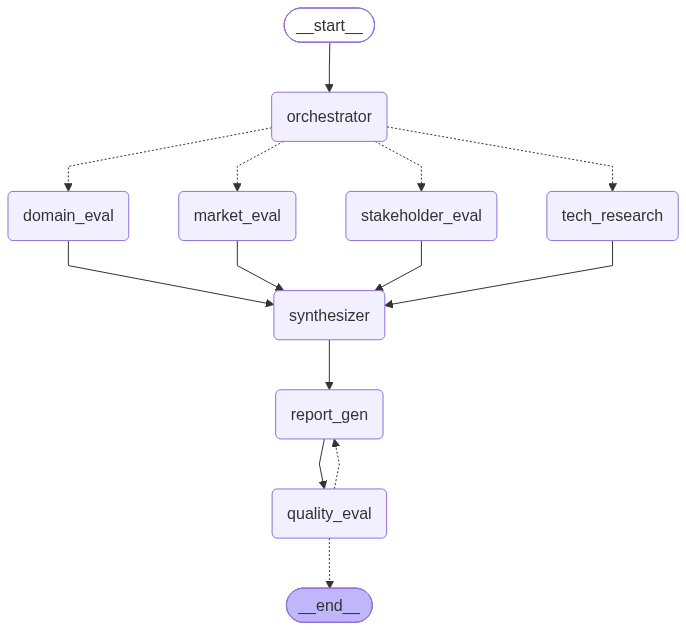

In [28]:
try:
    display(Image(full_graph.get_graph().draw_mermaid_png(max_retries=3, retry_delay=2.0)))
except Exception as e:
    print(f"그래프 이미지 렌더링 실패: {type(e).__name__}\n")
    print(full_graph.get_graph().draw_mermaid())

### 12-5. 실행

계획 → 워커 병렬 조사 → 종합 → 보고서 → 품질 평가(미달 시 재작성)까지 한 번에 실행.

- 앞의 9번 실행과는 별개의 새 실행이라 계획부터 다시 수행함 (LLM·검색 호출이 다시 발생)

In [29]:
full_run_id = uuid.uuid4().hex[:12]
full_config = {
    "configurable": {"thread_id": full_run_id},
    "run_name": f"kv-cache-eval-report-{full_run_id}",
    "tags": ["orchestrator-workers", "specialized-workers", "quality-loop", f"run:{full_run_id}"],
    "metadata": {"run_id": full_run_id},
}

full_result = full_graph.invoke(
    {
        "tech_sw": "DeepSeek-V2 (MLA)",
        "tech_hw": "ITME (Inference Tiered Memory Expansion)",
        "domain": "데이터센터/클라우드 서빙",
        "run_id": full_run_id,
        "tasks": {},
        "results": {},
        "decisions": [],
        "revision": 0,
    },
    config=full_config,
)

🧩 계획된 task 10개: 기술성숙도는 기술별 원문 분석과 TRL 추정이 필요하므로 분리했으며, 나머지 관점은 동일한 세부 기준 아래 두 기술을 함께 조사해 비교 가능한 근거를 수집하도록 구성했습니다. 모든 작업은 별도 자료 조사만으로 수행 가능하며, 종합 의견 작성은 포함하지 않았습니다.
   tech_research-1: 기술성숙도 관점 - SW MLA (target=sw)
   tech_research-2: 기술성숙도 관점 - HW ITME (target=hw)
   market_eval-1: 시장성 관점 - 시장 규모·성장성 (target=None)
   market_eval-2: 시장성 관점 - 상용화·채택 (target=None)
   market_eval-3: 시장성 관점 - 생태계 지지 (target=None)
   stakeholder_eval-1: 이해관계자 관점 - 경쟁 기술 진영 (target=None)
   stakeholder_eval-2: 이해관계자 관점 - 도입 기업·개발자 (target=None)
   stakeholder_eval-3: 이해관계자 관점 - 투자 업계 (target=None)
   domain_eval-1: 도메인 적용 관점 - 처리 가능 규모 (target=None)
   domain_eval-2: 도메인 적용 관점 - 비용 절감 (target=None)

==== [REPORT GEN] 1번째 작성 ====
outputs/report_orchestrator_workers.md 저장 완료

==== [QUALITY EVAL] 1번째 보고서 ====
  통과  Groundedness: [코드] 보고서의 URL이 모두 참고 자료 목록에 있음 / [LLM] 핵심 수치·사례·기술 설명은 근거 자료 또는 참고 자료 목록으로 추적된다. 예를 들어 MLA의 “KV cache 93.3%” 감소와 “최대 생성 처리량 5.76배”는 `DeepSeek-V2.pdf`로, SGLang의 “3~7배” 처리량은 SGLang v0.3 자료

### 12-6. 결과 확인

품질 평가가 몇 번 돌았고, 어떤 항목 때문에 재작성했는지, 최종 보고서가 통과했는지 확인.

In [30]:
show_run(full_result)

review = full_result["review"]
print(f"\n[품질 평가] 보고서 {full_result['revision']}회 작성, 최종 판정: "
      f"{'통과' if review['passed'] else '미달'}"
      + (f" ({review['error']})" if review.get("error") else ""))
for c in review["criteria"]:
    print(f"  {'통과' if c['passed'] else '미달'}  {c['name']}: {c['comment']}")

print(f"\n===== 최종 보고서 ({REPORT_PATH}) =====\n")
print(full_result["report"])

run_id=78ee5b73a4a8

[결정 로그]
  orchestrator     plan     ['tech_research-1', 'tech_research-2', 'market_eval-1', 'market_eval-2', 'market_eval-3', 'stakeholder_eval-1', 'stakeholder_eval-2', 'stakeholder_eval-3', 'domain_eval-1', 'domain_eval-2'] - 기술성숙도는 기술별 원문 분석과 TRL 추정이 필요하므로 분리했으며, 나머지 관점은 동일한 세부 기준 아래 두 기술을 함께 조사해 비교 가능한 근거를 수집하도록 구성했습니다. 모든 작업은 별도 자료 조사만으로 수행 가능하며, 종합 의견 작성은 포함하지 않았습니다.
  quality_eval     accept   [] - 1번째 보고서가 모든 항목 통과

[task 상태]
  tech_research-1     done     시도 1 기술성숙도 관점 - SW MLA
  tech_research-2     done     시도 1 기술성숙도 관점 - HW ITME
  market_eval-1       done     시도 1 시장성 관점 - 시장 규모·성장성
  market_eval-2       done     시도 1 시장성 관점 - 상용화·채택
  market_eval-3       done     시도 1 시장성 관점 - 생태계 지지
  stakeholder_eval-1  done     시도 1 이해관계자 관점 - 경쟁 기술 진영
  stakeholder_eval-2  done     시도 1 이해관계자 관점 - 도입 기업·개발자
  stakeholder_eval-3  done     시도 1 이해관계자 관점 - 투자 업계
  domain_eval-1       done     시도 1 도메인 적용 관점 - 처리 가능 규모
  domain_eval-2       done     시도 1 도메인 적용 관점 - 비용

-> LangSmith Tracing

- 프로젝트 `SKALA-KVCACHE`에서 `kv-cache-eval-specialized-<run_id>` 실행을 열면 orchestrator → 전문 워커 × N → synthesizer 흐름과 각 워커의 검색·LLM 호출을 확인할 수 있음
- 12번의 전체 실행은 `kv-cache-eval-report-<run_id>` 이름과 `quality-loop` 태그로 남고, 보고서 재작성이 일어났으면 `report_gen` → `quality_eval`이 반복된 것이 보임
- `specialized-workers` 태그로 범용 워커 버전의 실행과 구분됨

## 다음 단계

노트북에서 확인한 구조를 프로젝트 코드로 옮길 때 남은 작업:

- 노드별로 파일 분리 (`agents/orchestrator.py`, `agents/quality_eval.py`, 기존 `agents/*.py`를 워커 형태로 변경, `graph/state.py`, `graph/build_graph.py`)
- 프롬프트 파일에 `{instruction}`, `{feedback}` 자리와 중립성 등 작성 원칙을 직접 넣기 (지금은 노트북에서 덧붙임)
- 체크포인터를 `MemorySaver`에서 디스크 기반(`SqliteSaver`, `langgraph-checkpoint-sqlite` 설치 필요)으로 교체해 프로세스가 죽어도 재개 가능하게

---
End of Documents